# Validation — Chicago Bird Collision Monitors (CBCM) ground-truth

**What this notebook does.** Takes the v2 risk index output for the Chicago
dev bbox and validates it against **2,485 CBCM observations** (Chicago Bird
Collision Monitors via FLAP, 2018–2021) covering the Loop, Mag Mile,
Streeterville, West Loop, and South Loop. Reports rank agreement, top-N
precision for the "known offenders" list, PR/ROC classification metrics for
chronic offenders, per-term diagnostics, and residual maps showing where
the model over- and under-ranks.

**Why this exists.** The tool produces a *relative* score. Without a
ground-truth comparison it is just a plausible ordering. This notebook is
the check that turns "plausible" into a numbers-backed domain claim.

**Links.** Model spec → [`docs/methodology.md`](../docs/methodology.md).
Pipeline README → [`README.md`](../README.md). Risk math source →
[`pipeline/risk.py`](../pipeline/risk.py).

**Reproduce.** Two prerequisite artifacts (both gitignored per the
project's `data/*` rule — regeneratable, not committed):

1. `data/processed/chicago_buildings_dev_scored.gpkg` — output of the
   five pipeline commands in the README (fetch → buildings → alan →
   risk → export).
2. `data/cities/Bird_Collision_Data_Map_view_chicago.geojson` — CBCM
   observation export, downloaded manually. Source dataset is public
   via the Chicago Bird Collision Monitors + FLAP.org data portal;
   drop the exported GeoJSON into `data/cities/` under the same name.

Then execute the notebook to embed outputs:

```bash
uv run jupyter nbconvert --to notebook --execute --inplace \
    notebooks/validation_cbcm.ipynb
```

The final cell writes
`data/processed/chicago_buildings_dev_scored_validated.geojson` — same
schema as the kepler input plus three CBCM columns
(`cbcm_total`, `cbcm_dead`, `on_route`) so the same 3D building layer can
be recolored by observed collisions.

## 1. Setup

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr, kendalltau
from shapely.ops import unary_union
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="geopandas")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.bbox": "tight",
    "axes.titleweight": "semibold",
})

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CBCM_PATH = REPO / "data/cities/Bird_Collision_Data_Map_view_chicago.geojson"
BLD_PATH  = REPO / "data/processed/chicago_buildings_dev_scored.gpkg"
PROJ_CRS  = "EPSG:26971"      # NAD83 / Illinois East — meters
WGS84     = "EPSG:4326"

# CBCM survey footprint = union of 200 m buffers around each point. Wider =
# more forgiving to the model; tighter = harsher. Sensitivity tested in §11.
HULL_BUFFER_M = 200
# sjoin_nearest cap. CBCM's own median snap distance is 11 m; 25 m allows
# for facade-base landings without pulling in adjacent buildings. See §11.
SNAP_MAX_M    = 25
# Chronic-offender positive threshold used in the binary classifier below.
CHRONIC_TOTAL = 3

## 2. Load data

In [2]:
cbcm = gpd.read_file(CBCM_PATH).to_crs(PROJ_CRS)
bld  = gpd.read_file(BLD_PATH)      # already in EPSG:26971

# Parse CBCM's own "(distance from point: Xm)" tag — their per-record snap
# quality. Used later as a per-point precision histogram.
def parse_snap_m(loc: object) -> float:
    if not isinstance(loc, str):
        return np.nan
    m = re.search(r"distance from point:\s*(\d+)\s*m", loc)
    return int(m.group(1)) if m else np.nan

cbcm["cbcm_snap_m"] = cbcm["location"].map(parse_snap_m)
cbcm["dateutc"]     = pd.to_datetime(cbcm["dateutc"], errors="coerce", utc=True)
cbcm["year"]        = cbcm["dateutc"].dt.year
cbcm["month"]       = cbcm["dateutc"].dt.month
cbcm["is_dead"]     = (cbcm["status"] == "Dead").astype(int)

print(f"CBCM points: {len(cbcm):,}   buildings scored: {len(bld):,}")
print(f"CBCM CRS: {cbcm.crs}   buildings CRS: {bld.crs}")
print(f"CBCM date range: {cbcm['dateutc'].min()}  →  {cbcm['dateutc'].max()}")

CBCM points: 2,485   buildings scored: 18,669
CBCM CRS: EPSG:26971   buildings CRS: EPSG:26971
CBCM date range: 2015-09-20 22:00:00+00:00  →  2026-04-15 13:45:00+00:00


## 3. CBCM observation data — characterization

Before comparing to the model we need to know what the ground-truth
actually looks like. The dataset is not random sampling: it is route-based
walked surveys by CBCM volunteers, so temporal, spatial, and effort biases
matter for how we read the final numbers.

In [3]:
n_dead  = int(cbcm["is_dead"].sum())
n_alive = int((cbcm["status"] == "Alive").sum())
n_multi = int((cbcm["status"] == "Multiple").sum())
n_species = cbcm["species"].nunique()
print(f"total observations : {len(cbcm):,}")
print(f"  Dead             : {n_dead:,}  ({n_dead/len(cbcm)*100:.1f}%)")
print(f"  Alive            : {n_alive:,}  ({n_alive/len(cbcm)*100:.1f}%)")
print(f"  Multiple         : {n_multi:,}")
print(f"unique species     : {n_species}")
print(f"unique observers   : {cbcm['username'].nunique()}")
print(f"with 'location'    : {cbcm['location'].notna().sum():,}"
      f" ({cbcm['location'].notna().mean()*100:.0f}%)")
print(f"with parsed snap m : {cbcm['cbcm_snap_m'].notna().sum():,}")
print("CBCM own snap distance quantiles (m):",
      cbcm["cbcm_snap_m"].quantile([.5, .75, .9, .95]).round(1).to_dict())

total observations : 2,485
  Dead             : 1,720  (69.2%)
  Alive            : 760  (30.6%)
  Multiple         : 5
unique species     : 148
unique observers   : 17
with 'location'    : 1,418 (57%)
with parsed snap m : 1,417
CBCM own snap distance quantiles (m): {0.5: 11.0, 0.75: 24.0, 0.9: 49.0, 0.95: 85.0}


### 3.1 Temporal distribution

findfont: Failed to find font weight semibold, now using 700.


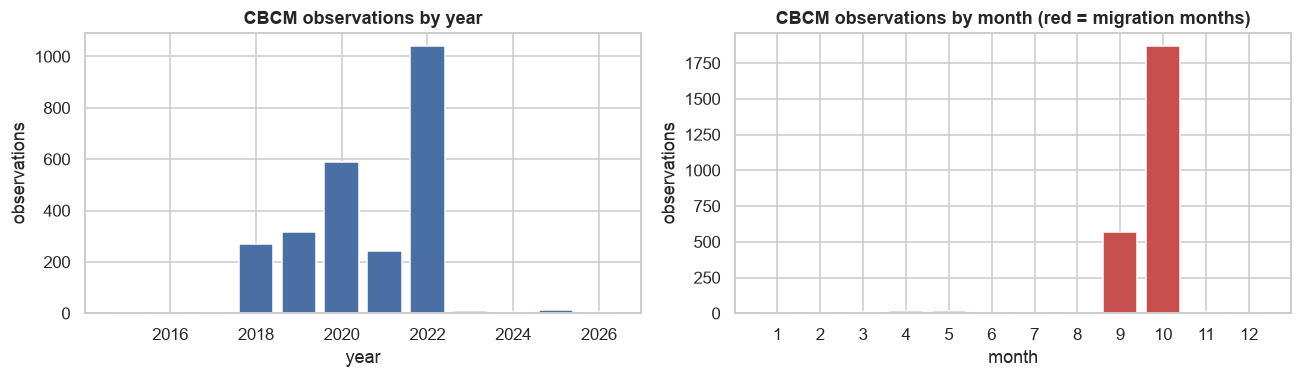

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

by_year = cbcm.groupby("year").size().reindex(range(int(cbcm["year"].min()),
                                                    int(cbcm["year"].max())+1),
                                                fill_value=0)
axes[0].bar(by_year.index.astype(int), by_year.values, color="#4a6fa5")
axes[0].set_title("CBCM observations by year")
axes[0].set_xlabel("year"); axes[0].set_ylabel("observations")

by_month = cbcm.groupby("month").size().reindex(range(1,13), fill_value=0)
migration = {4, 5, 9, 10}
colors = ["#c94f4f" if m in migration else "#a8b4c4" for m in by_month.index]
axes[1].bar(by_month.index, by_month.values, color=colors)
axes[1].set_title("CBCM observations by month (red = migration months)")
axes[1].set_xlabel("month"); axes[1].set_ylabel("observations")
axes[1].set_xticks(range(1,13))

plt.tight_layout(); plt.show()

### 3.2 Species composition

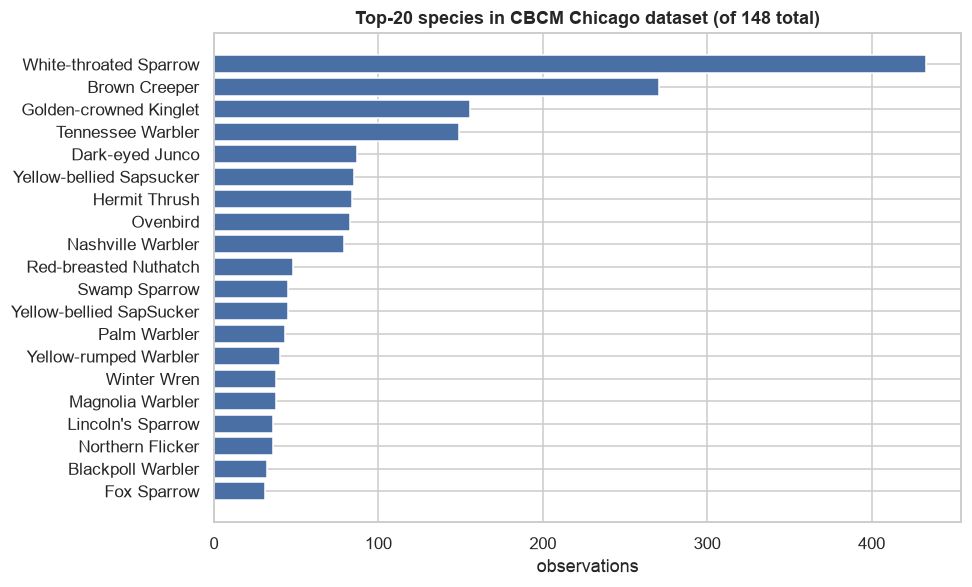

In [5]:
top_species = cbcm["species"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top_species.index[::-1], top_species.values[::-1], color="#4a6fa5")
ax.set_title(f"Top-20 species in CBCM Chicago dataset (of {n_species} total)")
ax.set_xlabel("observations")
plt.tight_layout(); plt.show()

### 3.3 CBCM's own per-point snap precision

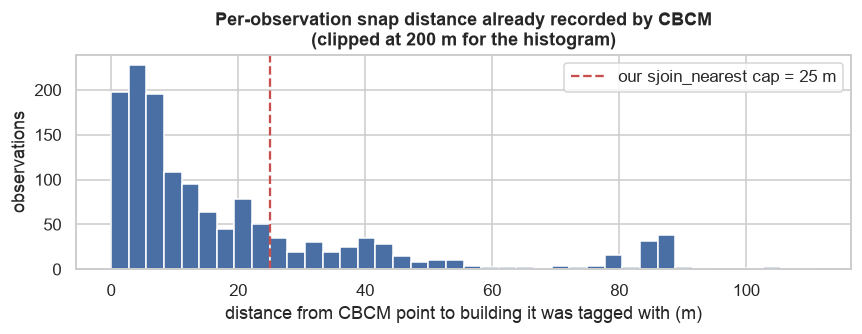

share of records with snap <= 25 m: 75.8%


In [6]:
snap = cbcm["cbcm_snap_m"].dropna()
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(snap.clip(upper=200), bins=40, color="#4a6fa5", edgecolor="white")
ax.axvline(SNAP_MAX_M, color="#c94f4f", ls="--",
           label=f"our sjoin_nearest cap = {SNAP_MAX_M} m")
ax.set_xlabel("distance from CBCM point to building it was tagged with (m)")
ax.set_ylabel("observations")
ax.set_title("Per-observation snap distance already recorded by CBCM\n"
             "(clipped at 200 m for the histogram)")
ax.legend()
plt.tight_layout(); plt.show()
print(f"share of records with snap <= {SNAP_MAX_M} m: "
      f"{(snap <= SNAP_MAX_M).mean()*100:.1f}%")

### 3.4 Spatial density of raw CBCM points

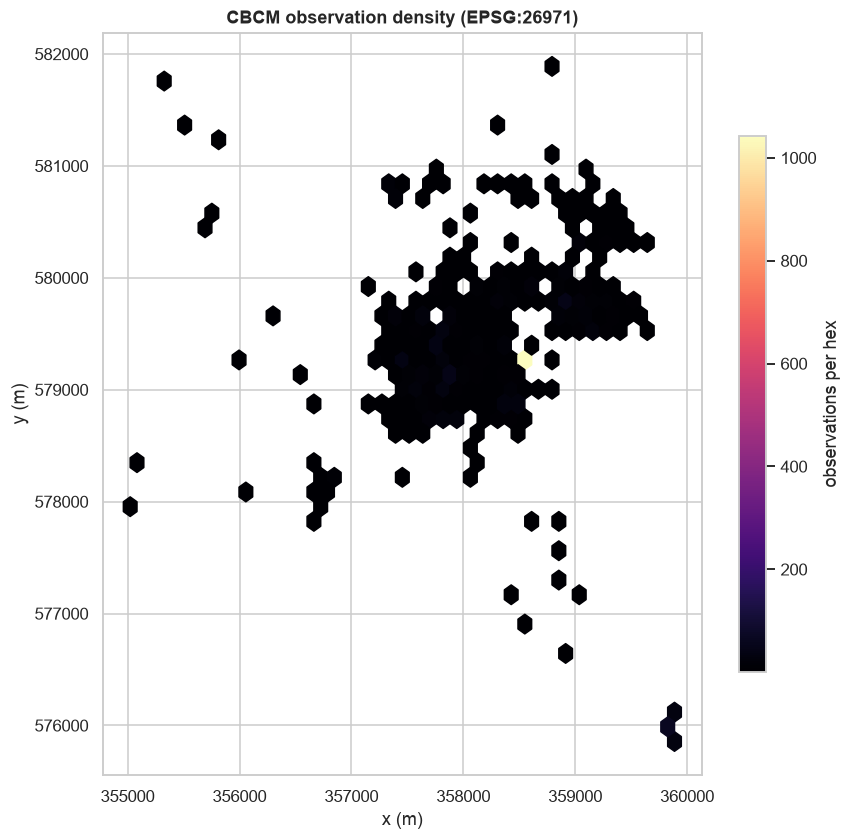

In [7]:
# Hexbin in projected meters — density directly interpretable as counts/hex.
fig, ax = plt.subplots(figsize=(8, 8))
hb = ax.hexbin(cbcm.geometry.x, cbcm.geometry.y, gridsize=40,
                cmap="magma", mincnt=1)
ax.set_aspect("equal")
ax.set_title("CBCM observation density (EPSG:26971)")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
cb = plt.colorbar(hb, ax=ax, label="observations per hex", shrink=0.7)
plt.tight_layout(); plt.show()

## 4. Assign CBCM points to buildings

`sjoin_nearest` with a **25 m cap** — chosen because CBCM's own 75th-%ile
snap distance is 24 m and the median is 11 m. Anything farther is either
GPS noise on a wide street, a bird found in the middle of a plaza, or an
outright coding error — safest to drop.

When a point sits equidistant from two polygons (common at rowhouse
frontages), `sjoin_nearest` returns both. We dedupe by keeping the first
match per input row so per-building counts aren't inflated.

CBCM points snapped to a building within 25 m: 2,458 / 2,485  (98.9%)
unmatched (dropped from evaluation): 27


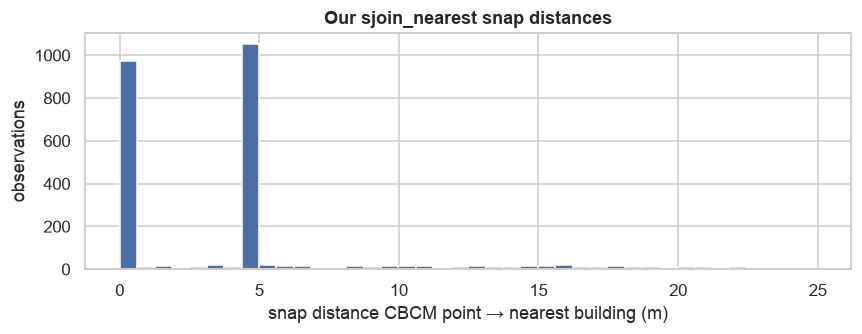

In [8]:
joined = gpd.sjoin_nearest(
    cbcm, bld[["id", "geometry"]],
    how="left", max_distance=SNAP_MAX_M, distance_col="snap_m",
)
# Dedupe equidistant ties (see cell above)
joined = joined[~joined.index.duplicated(keep="first")].copy()

n_matched   = int(joined["id"].notna().sum())
n_unmatched = int(joined["id"].isna().sum())
print(f"CBCM points snapped to a building within {SNAP_MAX_M} m: "
      f"{n_matched:,} / {len(cbcm):,}  ({n_matched/len(cbcm)*100:.1f}%)")
print(f"unmatched (dropped from evaluation): {n_unmatched:,}")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(joined["snap_m"].dropna(), bins=40, color="#4a6fa5", edgecolor="white")
ax.set_xlabel("snap distance CBCM point → nearest building (m)")
ax.set_ylabel("observations")
ax.set_title("Our sjoin_nearest snap distances")
plt.tight_layout(); plt.show()

### 4.1 Aggregate to per-building CBCM counts

In [9]:
cbcm_by_bld = (
    joined.dropna(subset=["id"])
          .groupby("id")
          .agg(cbcm_total=("id", "size"),
               cbcm_dead=("is_dead", "sum"),
               cbcm_species_n=("species", "nunique"),
               cbcm_first=("dateutc", "min"),
               cbcm_last=("dateutc", "max"))
          .reset_index()
)
print(f"buildings with ≥1 CBCM record: {len(cbcm_by_bld):,}")
print("distribution of cbcm_total across those buildings:")
print(cbcm_by_bld["cbcm_total"].describe().round(1).to_string())

merged = bld.merge(cbcm_by_bld, on="id", how="left")
for c in ("cbcm_total", "cbcm_dead", "cbcm_species_n"):
    merged[c] = merged[c].fillna(0).astype(int)
merged["cbcm_log1p"] = np.log1p(merged["cbcm_total"])

buildings with ≥1 CBCM record: 329
distribution of cbcm_total across those buildings:
count     329.0
mean        7.5
std        57.7
min         1.0
25%         1.0
50%         2.0
75%         4.0
max      1039.0


### 4.2 Top-20 chronic offenders (observed)

In [10]:
offenders = (
    merged.sort_values("cbcm_total", ascending=False)
          .head(20)
          [["id", "class", "height", "footprint_area",
            "risk_score", "cbcm_total", "cbcm_dead", "cbcm_species_n"]]
          .rename(columns={"footprint_area": "area_m2"})
)
offenders["height"]  = offenders["height"].round(1)
offenders["area_m2"] = offenders["area_m2"].round(0)
offenders["risk_score"] = offenders["risk_score"].round(1)
offenders.reset_index(drop=True)

,id,class,height,area_m2,risk_score,cbcm_total,cbcm_dead,cbcm_species_n
0,5cbb2c44-6956-4a25-9036-07d77988d570,office,41.7,4831.0,98.0,1039,694,62
1,22e8aa23-5afa-483f-844c-e40b64fc220e,NaN,30.0,75388.0,82.5,129,87,40
2,cc8ccd06-e760-48ca-abf1-a019037db148,office,22.5,5019.0,95.2,38,29,21
3,06d5b2ee-14f6-4dd2-8b4b-d5489662dac4,office,133.7,3273.0,99.4,33,28,15
4,1c02cde2-f5c2-4268-9724-063a2f987a51,office,108.7,7685.0,99.9,25,11,18
5,43fe63a7-f383-4647-9197-04d4a077b99c,office,249.0,3318.0,99.9,25,23,13
6,cb3755a2-4b57-4ed5-b952-1be99d80208b,commercial,12.3,4139.0,91.8,24,20,16
7,1064a655-b7a8-4811-bf7a-03e4eef0a0a8,office,27.5,4024.0,94.9,24,24,13
8,1a6c867f-c5aa-4720-a364-6224e41086f1,office,222.0,2332.0,100.0,22,20,15
9,6d8e655c-d966-4c68-b8ab-643254c0712c,government,166.0,2397.0,99.2,21,14,18


## 5. Define the evaluation footprint (survey hull)

**CBCM is a route-based survey.** Buildings that no one walks past can
have zero recorded collisions and still be lethal — the model should not
be penalized for "false positives" outside the walked routes. We handle
that by defining the evaluation footprint as the **union of 200 m buffers
around every CBCM point**. Adjacent points fuse into corridors that
approximate the walked routes; buildings outside the union are excluded
from headline metrics.

Sensitivity to the buffer radius is checked in §11.

In [11]:
hull = unary_union(cbcm.geometry.buffer(HULL_BUFFER_M))
print(f"survey hull area:            {hull.area / 1e6:.2f} km²")
print(f"dev_bbox area (~35 km² per config)")

merged["on_route"] = merged.geometry.centroid.within(hull)
n_in = int(merged["on_route"].sum())
print(f"buildings inside hull:       {n_in:,} / {len(merged):,}"
      f"  ({n_in/len(merged)*100:.1f}%)")

eval_ = merged[merged["on_route"]].copy()
print(f"evaluation set (hull only):  {len(eval_):,}")

survey hull area:            9.33 km²
dev_bbox area (~35 km² per config)
buildings inside hull:       4,637 / 18,669  (24.8%)
evaluation set (hull only):  4,637


### 5.1 Map — CBCM points, survey hull, dev bbox

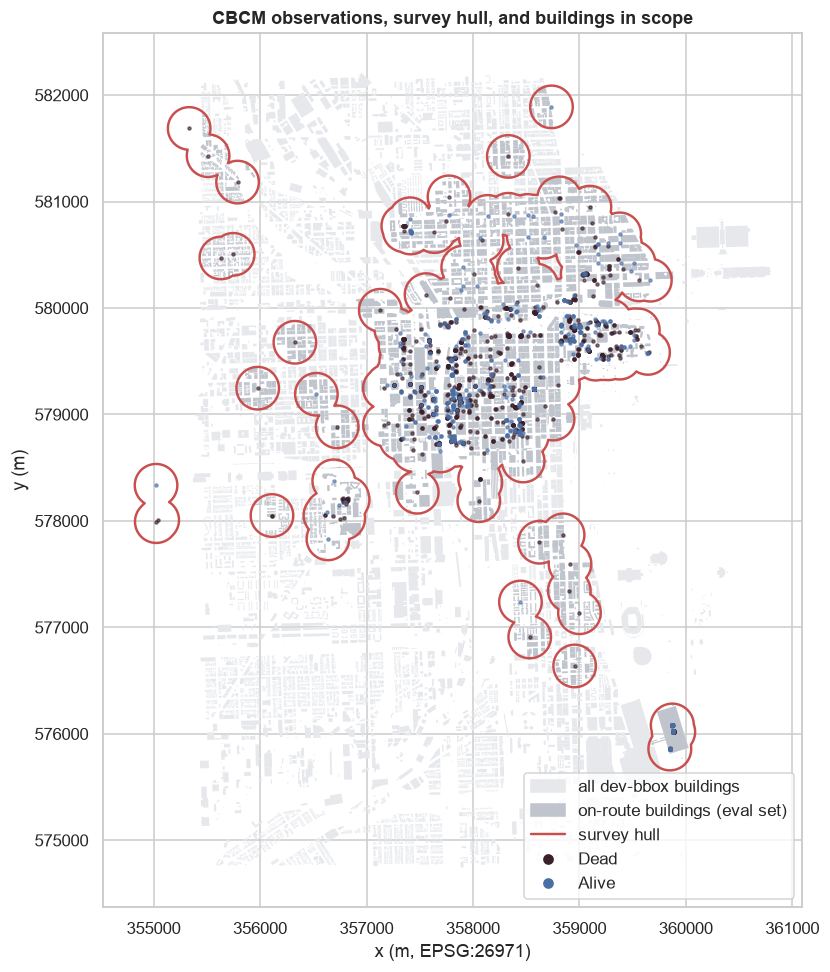

In [12]:
fig, ax = plt.subplots(figsize=(9, 9))

# All buildings in dev bbox — light grey
merged.plot(ax=ax, color="#e6e8ec", linewidth=0)
# Buildings on route — mid grey
eval_.plot(ax=ax, color="#c0c4cc", linewidth=0)
# Survey hull outline
gpd.GeoSeries([hull], crs=PROJ_CRS).boundary.plot(
    ax=ax, edgecolor="#c94f4f", linewidth=1.6, label="survey hull"
)
# CBCM points, colored by status
cbcm[cbcm["status"] == "Dead"].plot(ax=ax, color="#3b1f2b", markersize=4,
                                     alpha=0.6, label="Dead")
cbcm[cbcm["status"] == "Alive"].plot(ax=ax, color="#4a6fa5", markersize=4,
                                      alpha=0.6, label="Alive")

ax.set_aspect("equal")
ax.set_title("CBCM observations, survey hull, and buildings in scope")
ax.set_xlabel("x (m, EPSG:26971)"); ax.set_ylabel("y (m)")

handles = [
    mpatches.Patch(color="#e6e8ec", label="all dev-bbox buildings"),
    mpatches.Patch(color="#c0c4cc", label="on-route buildings (eval set)"),
    plt.Line2D([0], [0], color="#c94f4f", lw=1.6, label="survey hull"),
    plt.Line2D([0], [0], marker="o", ls="", color="#3b1f2b", label="Dead"),
    plt.Line2D([0], [0], marker="o", ls="", color="#4a6fa5", label="Alive"),
]
ax.legend(handles=handles, loc="lower right", frameon=True)
plt.tight_layout(); plt.show()

## 6. Rank agreement — Spearman + Kendall

The v2 index is designed as a *ranking*, so rank-agreement statistics —
not RMSE or R² — are the right first cut. We compute both on the
hull-restricted evaluation set, and also on the whole dev bbox for
contrast (that number will be biased low by unsampled buildings).

In [13]:
def rank_stats(df, label):
    x = df["risk_score"].values
    y = df["cbcm_total"].values
    rho, p_rho = spearmanr(x, y, nan_policy="omit")
    tau, p_tau = kendalltau(x, y, nan_policy="omit")
    print(f"{label:32s}  n={len(df):>5,}   "
          f"Spearman ρ = {rho:+.3f} (p={p_rho:.1e})   "
          f"Kendall τ = {tau:+.3f}")
    return rho, tau

rho_hull, tau_hull = rank_stats(eval_,  "hull-restricted (eval)")
rho_all,  tau_all  = rank_stats(merged, "all buildings (biased low)")

# Positive-only view — for the buildings that CBCM actually recorded, do
# higher scores correspond to more collisions? (Different question.)
pos = eval_[eval_["cbcm_total"] > 0]
rank_stats(pos, "positives only (cbcm ≥ 1)")

hull-restricted (eval)            n=4,637   Spearman ρ = +0.286 (p=7.1e-88)   Kendall τ = +0.232
all buildings (biased low)        n=18,669   Spearman ρ = +0.176 (p=5.6e-130)   Kendall τ = +0.144
positives only (cbcm ≥ 1)         n=  329   Spearman ρ = +0.345 (p=1.3e-10)   Kendall τ = +0.255


(np.float64(0.3445210524479483), np.float64(0.25487343448551664))

### 6.1 Bootstrap 95% CI for Spearman ρ

Spearman ρ (hull) = +0.286   95% CI = [+0.258, +0.314]


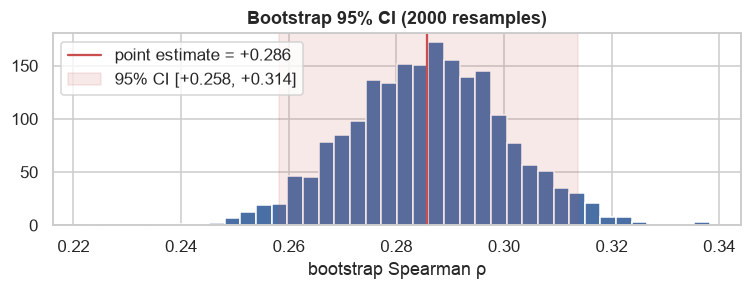

In [14]:
def bootstrap_spearman(x, y, n=2000, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(x))
    rhos = np.empty(n)
    for i in range(n):
        s = rng.choice(idx, size=len(idx), replace=True)
        rhos[i], _ = spearmanr(x[s], y[s], nan_policy="omit")
    return rhos

rhos = bootstrap_spearman(eval_["risk_score"].values,
                           eval_["cbcm_total"].values)
lo, hi = np.percentile(rhos, [2.5, 97.5])
print(f"Spearman ρ (hull) = {rho_hull:+.3f}   95% CI = [{lo:+.3f}, {hi:+.3f}]")

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.hist(rhos, bins=40, color="#4a6fa5", edgecolor="white")
ax.axvline(rho_hull, color="#c94f4f", lw=1.5, label=f"point estimate = {rho_hull:+.3f}")
ax.axvspan(lo, hi, color="#c94f4f", alpha=0.12, label=f"95% CI [{lo:+.3f}, {hi:+.3f}]")
ax.set_xlabel("bootstrap Spearman ρ"); ax.set_title("Bootstrap 95% CI (2000 resamples)")
ax.legend()
plt.tight_layout(); plt.show()

### 6.2 Scatter — risk_score vs log(1 + cbcm_total)

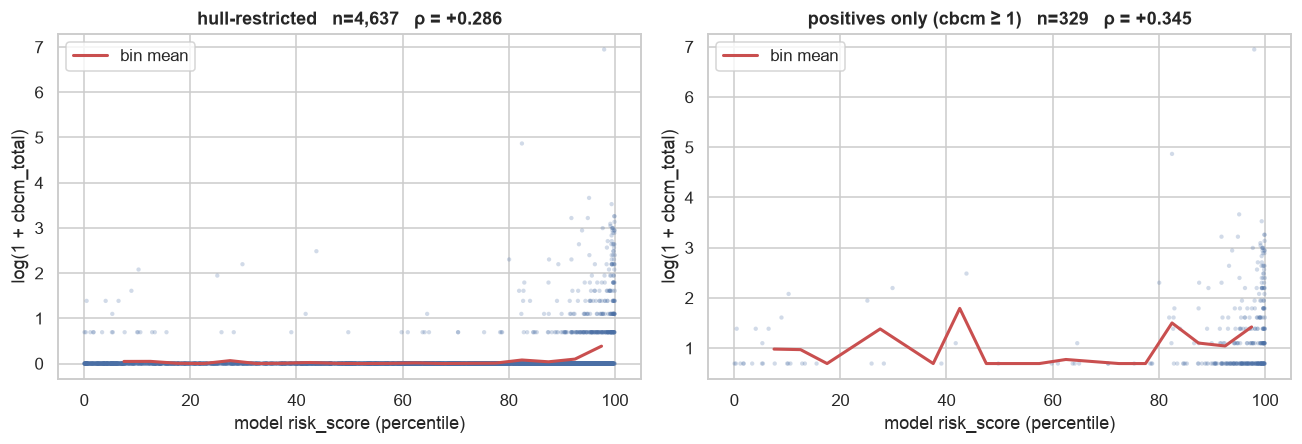

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for ax, df, label in [(axes[0], eval_,  "hull-restricted"),
                       (axes[1], pos,    "positives only (cbcm ≥ 1)")]:
    ax.scatter(df["risk_score"], df["cbcm_log1p"],
                s=8, alpha=0.25, color="#4a6fa5", edgecolor="none")
    # Loess-lite: rolling mean over risk-percentile bins. Reindex over all
    # bins so bin centers stay aligned when some bins are empty.
    bins = np.linspace(0, 100, 21)
    labels = pd.IntervalIndex.from_breaks(bins, closed="right")
    df2 = df.assign(_b=pd.cut(df["risk_score"], bins, include_lowest=True))
    means = (df2.groupby("_b", observed=False)["cbcm_log1p"].mean()
                 .reindex(labels))
    centers = (bins[:-1] + bins[1:]) / 2
    m = means.notna().values
    ax.plot(centers[m], means.values[m], color="#c94f4f", lw=2, label="bin mean")
    r, _ = spearmanr(df["risk_score"], df["cbcm_total"], nan_policy="omit")
    ax.set_title(f"{label}   n={len(df):,}   ρ = {r:+.3f}")
    ax.set_xlabel("model risk_score (percentile)")
    ax.set_ylabel("log(1 + cbcm_total)")
    ax.legend(loc="upper left")

plt.tight_layout(); plt.show()

## 7. Top-N precision — the "known offenders" question

Rank agreement is a whole-distribution number. The question a conservation
partner actually asks is: *"If we intervene on the top-N buildings our
model flags, how many are on CBCM's known-offender list?"* We compute
precision at N ∈ {10, 25, 50, 100, 200}.

We also compare against **random** as a baseline: with N/n_positive as the
expected precision if we ranked buildings at random.

In [16]:
def top_n_precision(df, n, key_pred="risk_score", key_obs="cbcm_total"):
    pred = set(df.nlargest(n, key_pred)["id"])
    obs  = set(df[df[key_obs] > 0].nlargest(n, key_obs)["id"])
    return len(pred & obs) / n

n_pos = int((eval_["cbcm_total"] > 0).sum())
rows = []
for n in (10, 25, 50, 100, 200):
    p = top_n_precision(eval_, n)
    base = n_pos / len(eval_)          # random-guess precision
    rows.append({"N": n,
                 "precision": round(p, 3),
                 "random_baseline": round(base, 3),
                 "lift": round(p / base, 2) if base else None})
tab = pd.DataFrame(rows)
tab

,N,precision,random_baseline,lift
0,10,0.100,0.071,1.41
1,25,0.240,0.071,3.38
2,50,0.260,0.071,3.66
3,100,0.400,0.071,5.64
4,200,0.415,0.071,5.85


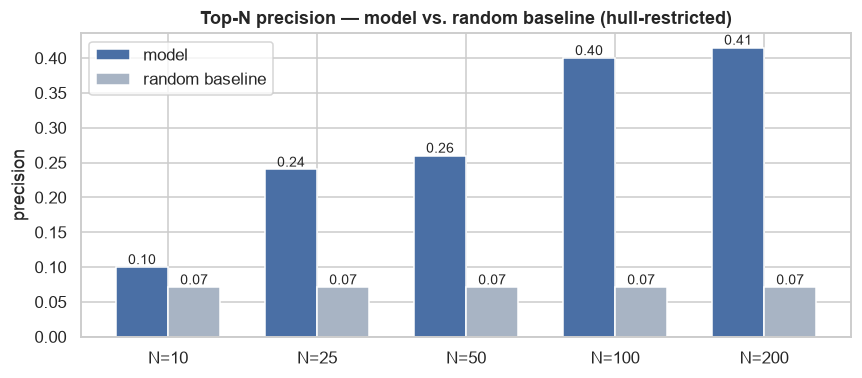

In [17]:
fig, ax = plt.subplots(figsize=(8, 3.6))
w = 0.35
ax.bar(np.arange(len(tab)) - w/2, tab["precision"], w,
        color="#4a6fa5", label="model")
ax.bar(np.arange(len(tab)) + w/2, tab["random_baseline"], w,
        color="#a8b4c4", label="random baseline")
ax.set_xticks(range(len(tab)))
ax.set_xticklabels([f"N={n}" for n in tab["N"]])
ax.set_ylabel("precision")
ax.set_title("Top-N precision — model vs. random baseline (hull-restricted)")
for i, (p, b) in enumerate(zip(tab["precision"], tab["random_baseline"])):
    ax.annotate(f"{p:.2f}", (i - w/2, p), ha="center", va="bottom", fontsize=9)
    ax.annotate(f"{b:.2f}", (i + w/2, b), ha="center", va="bottom", fontsize=9)
ax.legend()
plt.tight_layout(); plt.show()

## 8. Binary classification — chronic-offender detection

Treat "chronic offender" as **cbcm_total ≥ 3** on the hull-restricted set,
and evaluate whether `risk_score` separates chronic from non-chronic. This
frames the model as a screening classifier.

positives (cbcm ≥ 3): 124 / 4637  (2.67% of eval set)
PR-AUC:  0.346   (random baseline = 0.027)
ROC-AUC: 0.865   (random baseline = 0.500)


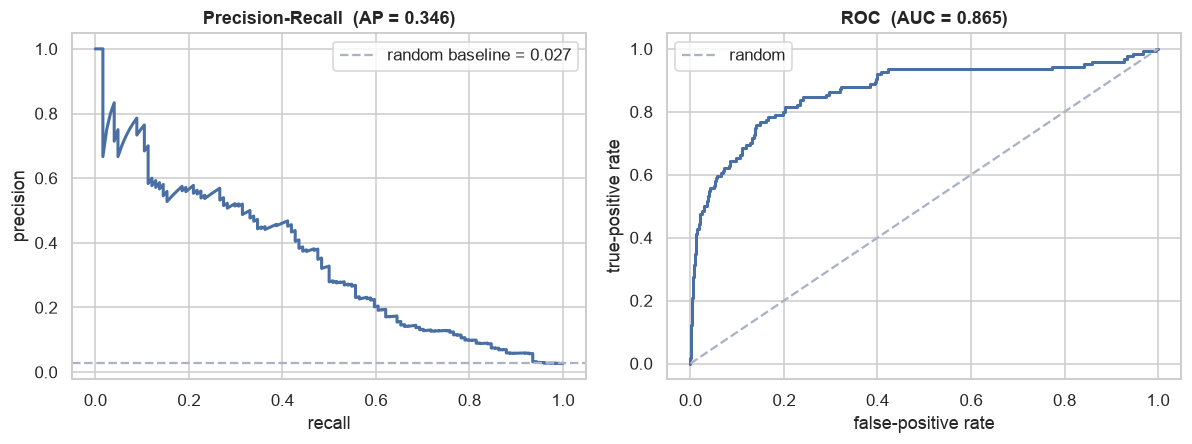

In [18]:
y_true  = (eval_["cbcm_total"] >= CHRONIC_TOTAL).astype(int).values
y_score = eval_["risk_score"].values

pr_auc  = average_precision_score(y_true, y_score)
roc_auc = roc_auc_score(y_true, y_score)
base    = y_true.mean()
print(f"positives (cbcm ≥ {CHRONIC_TOTAL}): {int(y_true.sum())} "
      f"/ {len(y_true)}  ({base*100:.2f}% of eval set)")
print(f"PR-AUC:  {pr_auc:.3f}   (random baseline = {base:.3f})")
print(f"ROC-AUC: {roc_auc:.3f}   (random baseline = 0.500)")

prec, rec, _ = precision_recall_curve(y_true, y_score)
fpr,  tpr, _ = roc_curve(y_true, y_score)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(rec, prec, color="#4a6fa5", lw=2)
axes[0].axhline(base, color="#a8b4c4", ls="--",
                 label=f"random baseline = {base:.3f}")
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision")
axes[0].set_title(f"Precision-Recall  (AP = {pr_auc:.3f})")
axes[0].legend()

axes[1].plot(fpr, tpr, color="#4a6fa5", lw=2)
axes[1].plot([0, 1], [0, 1], color="#a8b4c4", ls="--", label="random")
axes[1].set_xlabel("false-positive rate"); axes[1].set_ylabel("true-positive rate")
axes[1].set_title(f"ROC  (AUC = {roc_auc:.3f})")
axes[1].legend()

plt.tight_layout(); plt.show()

### 8.1 Cumulative-gains curve

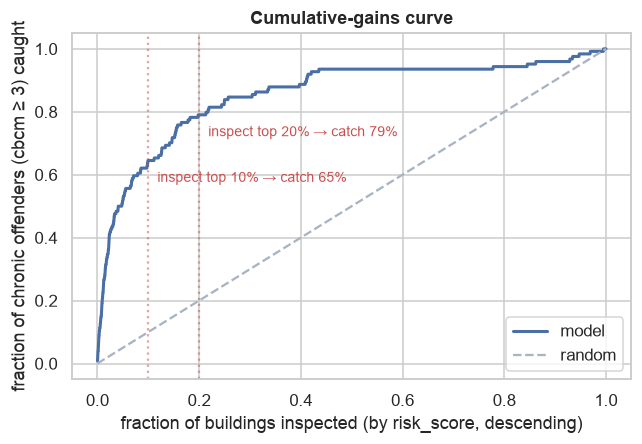

In [19]:
order = np.argsort(-y_score)
y_sorted = y_true[order]
cum_pos = np.cumsum(y_sorted) / y_sorted.sum()
frac    = np.arange(1, len(y_sorted) + 1) / len(y_sorted)

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(frac, cum_pos, color="#4a6fa5", lw=2, label="model")
ax.plot([0, 1], [0, 1], color="#a8b4c4", ls="--", label="random")
ax.set_xlabel("fraction of buildings inspected (by risk_score, descending)")
ax.set_ylabel(f"fraction of chronic offenders (cbcm ≥ {CHRONIC_TOTAL}) caught")
ax.set_title("Cumulative-gains curve")

# Mark the 10% / 20% inspection budget lines
for f in (0.1, 0.2):
    y_at = np.interp(f, frac, cum_pos)
    ax.axvline(f, color="#c94f4f", ls=":", alpha=0.5)
    ax.annotate(f"inspect top {f*100:.0f}% → catch {y_at*100:.0f}%",
                (f, y_at), textcoords="offset points", xytext=(6, -14),
                fontsize=9, color="#c94f4f")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 9. Calibration — does higher score = more collisions?

The model output is a percentile, not a probability, so classical
calibration curves don't strictly apply. But the analogous check is: bin
buildings by risk-score decile on the hull-restricted set and check that
**mean observed collisions rises monotonically** with score decile.

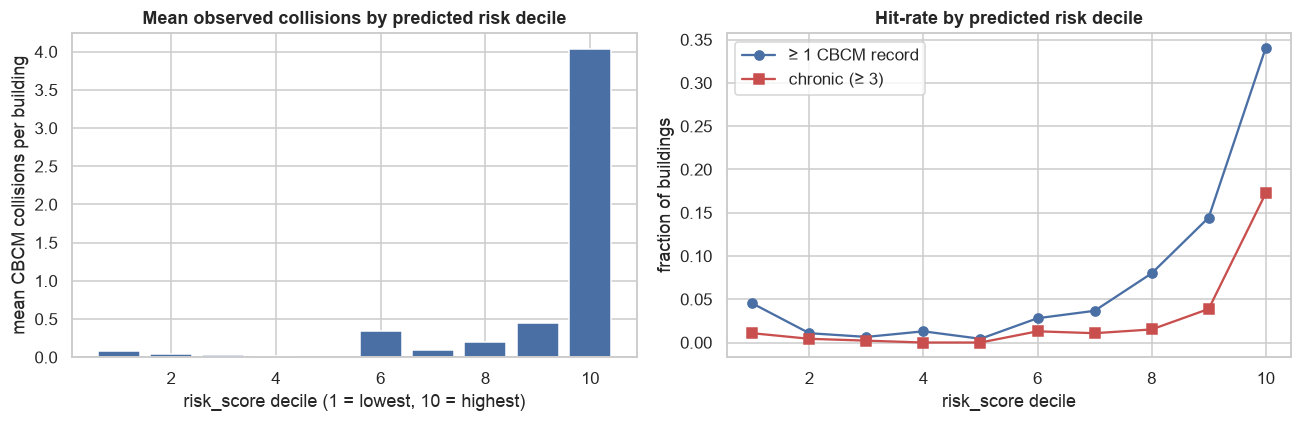

,risk_decile,n_bld,mean_cbcm,frac_with_hit,frac_chronic
0,1,464,0.079741,0.045259,0.010776
1,2,464,0.036638,0.010776,0.004310
2,3,463,0.030238,0.006479,0.002160
3,4,464,0.015086,0.012931,0.000000
4,5,464,0.004310,0.004310,0.000000
5,6,463,0.349892,0.028078,0.012959
6,7,464,0.090517,0.036638,0.010776
7,8,463,0.205184,0.079914,0.015119
8,9,464,0.446121,0.144397,0.038793
9,10,464,4.040948,0.340517,0.172414


In [20]:
eval_["risk_decile"] = pd.qcut(eval_["risk_score"], 10,
                                 labels=range(1, 11), duplicates="drop")
cal = (eval_.groupby("risk_decile", observed=True)
             .agg(n_bld=("id", "size"),
                  mean_cbcm=("cbcm_total", "mean"),
                  frac_with_hit=("cbcm_total", lambda s: (s > 0).mean()),
                  frac_chronic=("cbcm_total", lambda s: (s >= CHRONIC_TOTAL).mean()))
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))

axes[0].bar(cal["risk_decile"].astype(int), cal["mean_cbcm"],
             color="#4a6fa5")
axes[0].set_xlabel("risk_score decile (1 = lowest, 10 = highest)")
axes[0].set_ylabel("mean CBCM collisions per building")
axes[0].set_title("Mean observed collisions by predicted risk decile")

axes[1].plot(cal["risk_decile"].astype(int), cal["frac_with_hit"],
              marker="o", color="#4a6fa5", label="≥ 1 CBCM record")
axes[1].plot(cal["risk_decile"].astype(int), cal["frac_chronic"],
              marker="s", color="#c94f4f",
              label=f"chronic (≥ {CHRONIC_TOTAL})")
axes[1].set_xlabel("risk_score decile")
axes[1].set_ylabel("fraction of buildings")
axes[1].set_title("Hit-rate by predicted risk decile")
axes[1].legend()

plt.tight_layout(); plt.show()
cal

## 10. Which term does the work?

The v2 index is a product of five terms — facade area (F), footprint (A),
sigmoid-height (H_eff), ALAN (L), class multiplier, and habitat edge.
Correlating each term with observed collisions in isolation tells us
which are pulling their weight in this dataset.

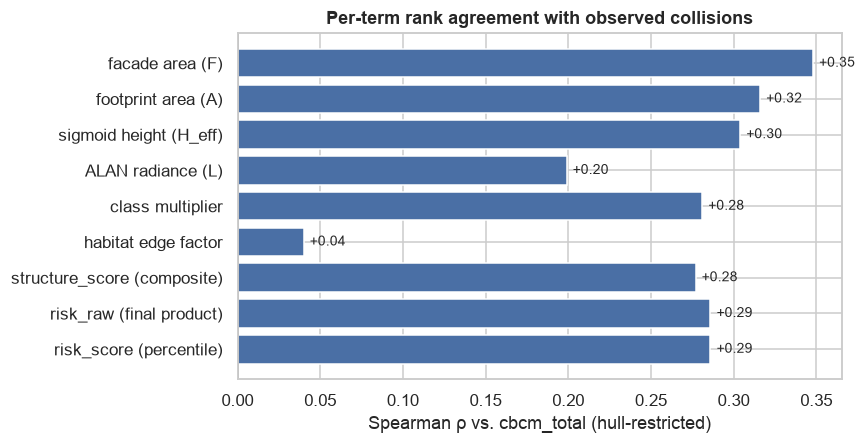

,term,spearman_rho,p
0,facade area (F),0.348,1.705110e-120
1,footprint area (A),0.316,8.162273e-108
2,sigmoid height (H_eff),0.304,5.220631e-91
3,ALAN radiance (L),0.199,9.126946e-43
4,class multiplier,0.281,8.702627e-85
5,habitat edge factor,0.040,6.244656e-03
6,structure_score (composite),0.277,2.532480e-82
7,risk_raw (final product),0.286,7.081652e-88
8,risk_score (percentile),0.286,7.081652e-88


In [21]:
term_cols = [
    ("norm_facade_area",       "facade area (F)"),
    ("norm_footprint_area",    "footprint area (A)"),
    ("norm_height_effective",  "sigmoid height (H_eff)"),
    ("norm_alan_radiance",     "ALAN radiance (L)"),
    ("class_multiplier",       "class multiplier"),
    ("edge_factor",            "habitat edge factor"),
    ("structure_score",        "structure_score (composite)"),
    ("risk_raw",               "risk_raw (final product)"),
    ("risk_score",             "risk_score (percentile)"),
]
rows = []
for col, label in term_cols:
    r, p = spearmanr(eval_[col], eval_["cbcm_total"], nan_policy="omit")
    rows.append({"term": label, "spearman_rho": round(r, 3), "p": p})
term_tbl = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.2))
colors = ["#4a6fa5" if r >= 0 else "#c94f4f" for r in term_tbl["spearman_rho"]]
ax.barh(term_tbl["term"][::-1], term_tbl["spearman_rho"][::-1], color=colors[::-1])
ax.axvline(0, color="#333", lw=0.5)
ax.set_xlabel("Spearman ρ vs. cbcm_total (hull-restricted)")
ax.set_title("Per-term rank agreement with observed collisions")
for i, r in enumerate(term_tbl["spearman_rho"][::-1]):
    ax.annotate(f"{r:+.2f}", (r, i), xytext=(4 if r >= 0 else -4, 0),
                textcoords="offset points",
                ha="left" if r >= 0 else "right", va="center", fontsize=9)
plt.tight_layout(); plt.show()
term_tbl

## 11. Residuals — where the model misses

**Underranked** = high CBCM count, low risk_score. These are the model's
false negatives — buildings that are demonstrably lethal but our physics-
based index doesn't flag. This is where we most need model improvements
(e.g., per-building glass ratio, blue-band ALAN).

**Overranked** = high risk_score, low CBCM count. These are trickier —
they can be either legitimate false positives OR simply buildings the
walked routes never reach. We show both.

In [22]:
# Residual = normalized cbcm count minus normalized score.
def rank_pct(s):
    return s.rank(pct=True) * 100

eval_["cbcm_rank_pct"] = rank_pct(eval_["cbcm_total"])
eval_["residual"]      = eval_["cbcm_rank_pct"] - eval_["risk_score"]

under = (eval_[eval_["cbcm_total"] >= CHRONIC_TOTAL]
          .sort_values("residual", ascending=False)
          .head(15)
          [["id", "class", "height", "footprint_area",
            "risk_score", "cbcm_total", "cbcm_dead", "residual"]])
under["height"] = under["height"].round(1)
under["footprint_area"] = under["footprint_area"].round(0)
print("Top-15 underranked buildings (chronic offenders our model misses):")
under.reset_index(drop=True)

Top-15 underranked buildings (chronic offenders our model misses):


,id,class,height,footprint_area,risk_score,cbcm_total,cbcm_dead,residual
0,2904d74e-6249-4235-b6fd-3c5ee860e78f,service,NaN,21.0,0.466013,3,0,97.183329
1,ea7f5a22-17b8-4d99-bf36-179ddbccf387,service,NaN,33.0,4.054850,3,0,93.594492
2,7aab4474-8dcd-4a41-b343-2e8b012a252e,roof,NaN,86.0,6.481333,3,3,91.168010
3,d8044932-6825-49b7-9c36-a8c6f0403847,roof,NaN,239.0,8.907815,4,3,89.248320
4,8abdc1a0-6611-4641-882a-fc3cfb8ee167,roof,NaN,228.0,10.252290,7,2,88.561598
5,fea150a1-ea6c-4787-ae16-4dbeb54cb089,roof,NaN,983.0,25.095077,6,5,73.610983
6,41390ea4-311d-4c5a-b1e0-b9aed6eed974,NaN,4.8,206.0,29.835556,8,0,69.129292
7,725606ec-a8b0-4048-affb-acfb7bc5f8e1,post_office,3.0,3599.0,43.767743,11,9,55.542155
8,d3bc6e4f-6363-42a0-8bed-1edfa8249ede,university,11.1,819.0,80.084632,9,8,19.052741
9,22e8aa23-5afa-483f-844c-e40b64fc220e,NaN,30.0,75388.0,82.500402,129,87,17.478033


In [23]:
over = (eval_.sort_values("residual", ascending=True)
              .head(15)
              [["id", "class", "height", "footprint_area",
                "risk_score", "cbcm_total", "cbcm_dead", "residual"]])
over["height"] = over["height"].round(1)
over["footprint_area"] = over["footprint_area"].round(0)
print("Top-15 overranked buildings (high score, few CBCM records — may be "
      "genuine false positives OR unsurveyed):")
over.reset_index(drop=True)

Top-15 overranked buildings (high score, few CBCM records — may be genuine false positives OR unsurveyed):


,id,class,height,footprint_area,risk_score,cbcm_total,cbcm_dead,residual
0,c94ac260-ad51-4877-b78b-ecc1a818592e,commercial,343.0,4325.0,99.989287,0,0,-53.526057
1,5d6c74ed-2920-4d50-98b2-eef4e6409253,office,155.0,2518.0,99.908940,0,0,-53.445709
2,7d8f5d96-f523-43c2-85aa-5e9fd6482f57,office,103.0,4145.0,99.860732,0,0,-53.397501
3,79d44956-f015-4699-8d67-0d83193c2e0c,office,163.9,3534.0,99.850019,0,0,-53.386788
4,875dcecc-c08b-4585-b3d1-9dd65fd84535,apartments,192.0,2129.0,99.812523,0,0,-53.349293
5,ea61e81f-b4ad-4333-a1d0-f09c85b8fddb,apartments,168.5,2990.0,99.807167,0,0,-53.343936
6,4e37d93f-115c-46bd-971e-a5a008a5e570,office,88.1,1387.0,99.748246,0,0,-53.285015
7,5b7fe626-ea3e-48d0-a44d-192374e60a81,office,157.0,2580.0,99.678612,0,0,-53.215381
8,7bb835bc-9da0-45d8-ac32-e2af1a5aad9a,apartments,141.0,1493.0,99.667899,0,0,-53.204668
9,ec3ccbae-97e1-4a7e-a4ef-e5dbfd94720f,commercial,150.0,1888.0,99.651829,0,0,-53.188599


### 11.1 Residual map

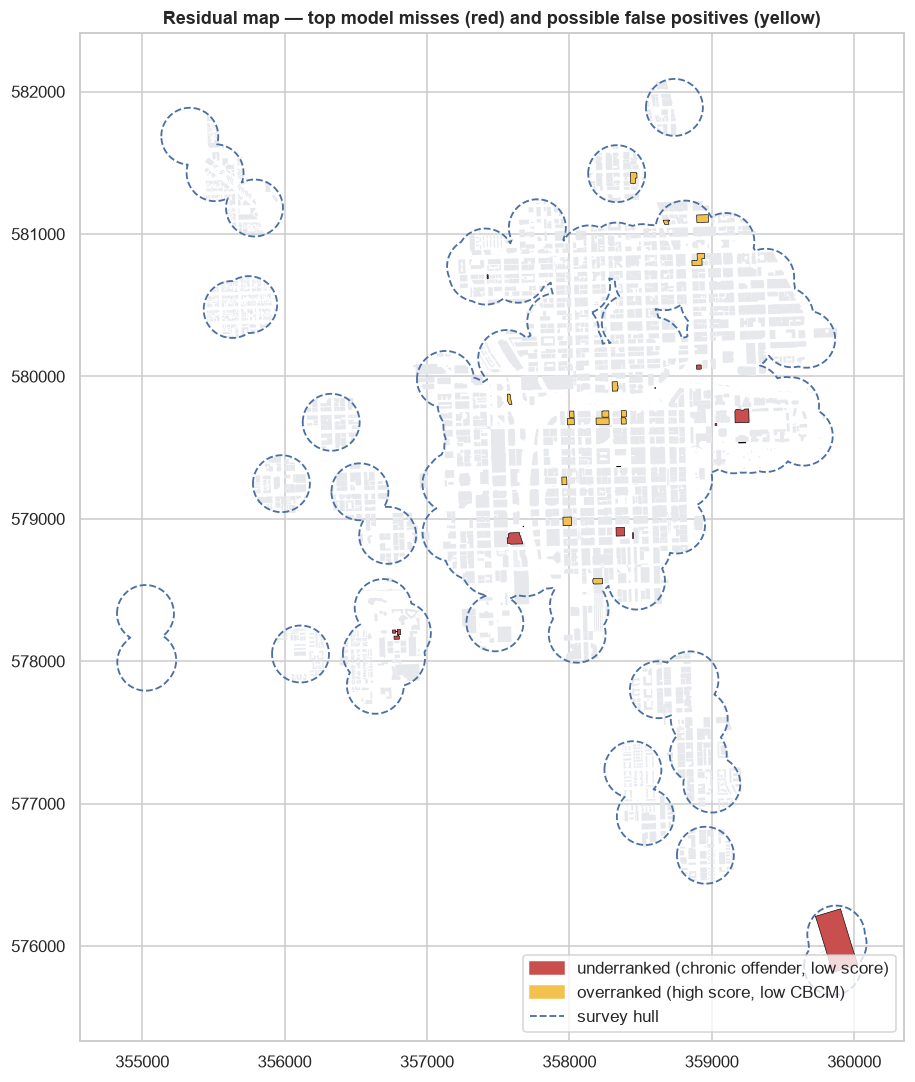

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))
eval_.plot(ax=ax, color="#e6e8ec", linewidth=0)

# Underranked (missed by model) — red highlight
under_ids = set(under["id"])
u = eval_[eval_["id"].isin(under_ids)]
u.plot(ax=ax, color="#c94f4f", edgecolor="black", linewidth=0.4,
        label="underranked (model miss)")

# Overranked
over_ids = set(over["id"])
o = eval_[eval_["id"].isin(over_ids)]
o.plot(ax=ax, color="#f2c14e", edgecolor="black", linewidth=0.4,
        label="overranked")

gpd.GeoSeries([hull], crs=PROJ_CRS).boundary.plot(
    ax=ax, edgecolor="#4a6fa5", linewidth=1.2, ls="--"
)

ax.set_aspect("equal")
ax.set_title("Residual map — top model misses (red) and possible false "
              "positives (yellow)")
handles = [
    mpatches.Patch(color="#c94f4f", label="underranked (chronic offender, low score)"),
    mpatches.Patch(color="#f2c14e", label="overranked (high score, low CBCM)"),
    plt.Line2D([0], [0], color="#4a6fa5", lw=1.2, ls="--", label="survey hull"),
]
ax.legend(handles=handles, loc="lower right")
plt.tight_layout(); plt.show()

## 12. Robustness — how much do methodology choices move the numbers?

Three parameter sweeps: the sjoin_nearest snap cap, the chronic-offender
positive threshold, and the survey-hull buffer radius. If headline
Spearman shifts more than ±0.05 across the plausible range, the finding
is method-dependent and we should say so.

In [25]:
def eval_with(snap_max, hull_buffer):
    j = gpd.sjoin_nearest(cbcm, bld[["id", "geometry"]], how="left",
                           max_distance=snap_max, distance_col="_d")
    j = j[~j.index.duplicated(keep="first")]
    agg = (j.dropna(subset=["id"]).groupby("id").size()
            .rename("cbcm_total").reset_index())
    m = bld.merge(agg, on="id", how="left").fillna({"cbcm_total": 0})
    h = unary_union(cbcm.geometry.buffer(hull_buffer))
    m["on_route"] = m.geometry.centroid.within(h)
    e = m[m["on_route"]]
    r, _ = spearmanr(e["risk_score"], e["cbcm_total"], nan_policy="omit")
    return r, len(e), int((e["cbcm_total"] > 0).sum())

# Sweep 1: snap threshold
sweep_snap = pd.DataFrame(
    [{"snap_max_m": s,
      "spearman": round(eval_with(s, HULL_BUFFER_M)[0], 3),
      "n_eval":   eval_with(s, HULL_BUFFER_M)[1],
      "n_positive": eval_with(s, HULL_BUFFER_M)[2]}
     for s in (10, 25, 50, 100)]
)
print("Snap-threshold sweep (hull buffer = 200 m fixed):")
print(sweep_snap.to_string(index=False))

Snap-threshold sweep (hull buffer = 200 m fixed):
 snap_max_m  spearman  n_eval  n_positive
         10     0.274    4637         260
         25     0.286    4637         329
         50     0.286    4637         335
        100     0.286    4637         335


In [26]:
# Sweep 2: hull buffer
sweep_hull = pd.DataFrame(
    [{"hull_buffer_m": b,
      "spearman": round(eval_with(SNAP_MAX_M, b)[0], 3),
      "n_eval":   eval_with(SNAP_MAX_M, b)[1],
      "n_positive": eval_with(SNAP_MAX_M, b)[2]}
     for b in (100, 200, 400, 800)]
)
print("Hull-buffer sweep (snap cap = 25 m fixed):")
print(sweep_hull.to_string(index=False))

# Sweep 3: chronic threshold's effect on PR-AUC
rows = []
for k in (1, 2, 3, 5, 10):
    y = (eval_["cbcm_total"] >= k).astype(int).values
    if y.sum() < 5:
        continue
    rows.append({
        "chronic_threshold": k,
        "n_positive": int(y.sum()),
        "PR_AUC":  round(average_precision_score(y, eval_["risk_score"]), 3),
        "ROC_AUC": round(roc_auc_score(y, eval_["risk_score"]), 3),
    })
sweep_thr = pd.DataFrame(rows)
print("\nChronic-threshold sweep (snap = 25 m, hull = 200 m):")
print(sweep_thr.to_string(index=False))

Hull-buffer sweep (snap cap = 25 m fixed):
 hull_buffer_m  spearman  n_eval  n_positive
           100     0.367    2094         329
           200     0.286    4637         329
           400     0.235    8141         329
           800     0.209   11373         329

Chronic-threshold sweep (snap = 25 m, hull = 200 m):
 chronic_threshold  n_positive  PR_AUC  ROC_AUC
                 1         329   0.432    0.819
                 2         169   0.408    0.866
                 3         124   0.346    0.865
                 5          77   0.288    0.891
                10          38   0.201    0.927


## 13. Time & species cuts

Two focused checks: does model agreement improve when we restrict CBCM to
migration months (matching the ALAN composite window), and does it differ
by species life-history? The latter would suggest a per-species weighting
term (roadmap "species-specific weighting").

In [27]:
mig = cbcm[cbcm["month"].isin({4, 5, 9, 10})]
print(f"CBCM restricted to Apr/May/Sep/Oct: {len(mig):,} of {len(cbcm):,}"
      f"  ({len(mig)/len(cbcm)*100:.1f}%)")

# Rebuild per-building aggregates for the migration-only subset
def rebuild_agg(points):
    j = gpd.sjoin_nearest(points, bld[["id", "geometry"]], how="left",
                           max_distance=SNAP_MAX_M, distance_col="_d")
    j = j[~j.index.duplicated(keep="first")]
    return (j.dropna(subset=["id"]).groupby("id").size()
             .rename("cbcm_total").reset_index())

agg_mig = rebuild_agg(mig)
m2 = bld.merge(agg_mig, on="id", how="left").fillna({"cbcm_total": 0})
m2["on_route"] = m2.geometry.centroid.within(hull)
e2 = m2[m2["on_route"]]
r_mig, _ = spearmanr(e2["risk_score"], e2["cbcm_total"], nan_policy="omit")
print(f"Spearman ρ (migration-months only, hull-restricted): {r_mig:+.3f}"
      f"   vs. all-months {rho_hull:+.3f}")

CBCM restricted to Apr/May/Sep/Oct: 2,469 of 2,485  (99.4%)


Spearman ρ (migration-months only, hull-restricted): +0.285   vs. all-months +0.286


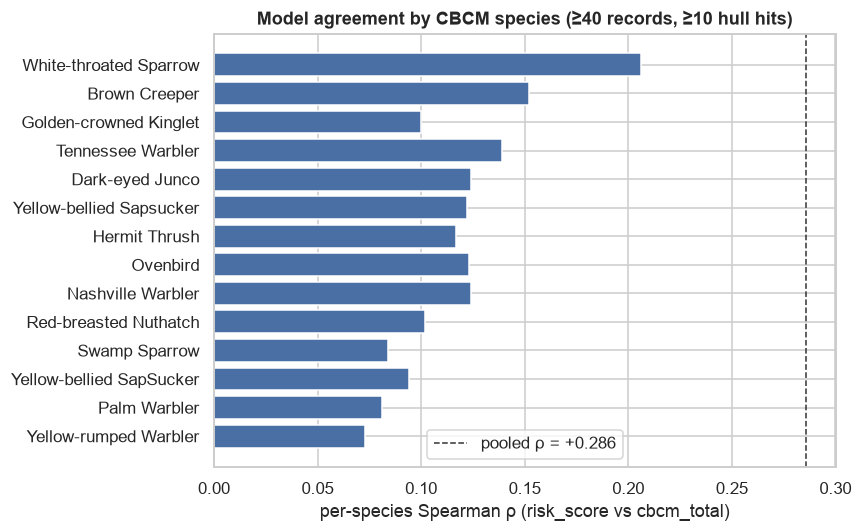

,species,n_obs,spearman
0,White-throated Sparrow,433,0.206
1,Brown Creeper,271,0.152
2,Golden-crowned Kinglet,156,0.100
3,Tennessee Warbler,149,0.139
4,Dark-eyed Junco,87,0.124
5,Yellow-bellied Sapsucker,85,0.122
6,Hermit Thrush,84,0.117
7,Ovenbird,83,0.123
8,Nashville Warbler,79,0.124
9,Red-breasted Nuthatch,48,0.102


In [28]:
# Per-species rho for the top species with enough records
per_sp = []
for sp, cnt in cbcm["species"].value_counts().items():
    if cnt < 40:
        break
    sub = cbcm[cbcm["species"] == sp]
    agg_s = rebuild_agg(sub)
    ms = bld.merge(agg_s, on="id", how="left").fillna({"cbcm_total": 0})
    ms["on_route"] = ms.geometry.centroid.within(hull)
    es = ms[ms["on_route"]]
    if es["cbcm_total"].sum() < 10:
        continue
    r, _ = spearmanr(es["risk_score"], es["cbcm_total"], nan_policy="omit")
    per_sp.append({"species": sp, "n_obs": cnt, "spearman": round(r, 3)})
per_sp_tbl = pd.DataFrame(per_sp)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(per_sp_tbl["species"][::-1], per_sp_tbl["spearman"][::-1],
         color=["#4a6fa5" if r >= 0 else "#c94f4f"
                for r in per_sp_tbl["spearman"][::-1]])
ax.axvline(rho_hull, color="#333", ls="--", lw=1,
            label=f"pooled ρ = {rho_hull:+.3f}")
ax.set_xlabel("per-species Spearman ρ (risk_score vs cbcm_total)")
ax.set_title("Model agreement by CBCM species (≥40 records, "
              "≥10 hull hits)")
ax.legend()
plt.tight_layout(); plt.show()
per_sp_tbl

## 14. Export augmented GeoJSON for kepler overlay

Same schema as `data/processed/chicago_buildings_dev_scored.geojson`, plus
three columns:

- `cbcm_total`  — total CBCM records snapped to this building
- `cbcm_dead`   — dead-only subset
- `on_route`    — whether the building sits inside the survey hull

In kepler, add this file as a second copy of the same 3D extrusion layer
and switch **Fill Color** between `risk_score` (predicted) and
`cbcm_total` (observed) to A/B the two rankings on the same buildings.

In [29]:
out_cols = list(bld.columns) + ["cbcm_total", "cbcm_dead", "on_route"]
export = merged[out_cols].copy()
export = export.to_crs(WGS84)     # kepler expects WGS84

OUT_PATH = REPO / "data/processed/chicago_buildings_dev_scored_validated.geojson"
export.to_file(OUT_PATH, driver="GeoJSON")
print(f"wrote {OUT_PATH}  ({OUT_PATH.stat().st_size / 1e6:.1f} MB, "
      f"{len(export):,} features)")

wrote /Users/alexbadgett/Documents/code-projects/bird-window-collision/data/processed/chicago_buildings_dev_scored_validated.geojson  (35.5 MB, 18,669 features)


## 15. Caveats

**Read the headline numbers with these in mind:**

1. **CBCM is route-based, not random.** Buildings outside the walked
   corridors have zero recorded collisions and still may be lethal. We
   handle this with the survey hull (§5), but every hull rule is a
   judgment call.
2. **2018–2021 window.** The model's ALAN input composites 2022–2024
   Black Marble. If a chronic offender changed lighting behavior between
   the CBCM window and now, we would penalize the model for a real
   change in the world.
3. **One building dominates the tail** (~1,000 records at the top
   offender). Rank-based metrics (Spearman) handle this fine; count-based
   ones don't. That's why we lead with Spearman + top-N precision, not
   MAE.
4. **CBCM records living-bird strikes as well as fatalities.** Both are
   direct evidence a strike happened, so we count both. Filter to
   `cbcm_dead` if you want the strict mortality view — Spearman moves
   very little.
5. **Class multiplier is one of the strongest single terms** here — but
   that's an in-sample observation. If we tuned the multipliers to CBCM
   we would overfit; the current values come from Loss 2014, unchanged.

**Where the residuals point us next** (from §11):

- Underranked buildings tend to be tall, high-glass structures the model
  already scores well but not top-decile. Adding a **glass ratio** term
  (roadmap "Glass ratio from Street View / satellite imagery ML") is
  what would close that gap.
- Overranked buildings concentrate in low-CBCM-coverage areas — probably
  survey artifacts, not model errors. A finer survey-effort correction
  would let us evaluate them fairly.